# Кластеризация сигналов сцинтилляционного детектора (v8 — prep EPIC-PREP-0808)

**ФИО:** Анастасия Волконская  
**Группа:** М25-555

ссылка на соревнование Kaggle
https://www.kaggle.com/competitions/signal-types-classification


❗Загрузите датасет /Run200_Wave_0_1.txt через панель слева: Файлы / Files (значок папки на вертикальной панели инструментов в левой части экрана) **перед** запуском Run All; код будет читать только этот путь и выполнится без задержек.


In [1]:
# @title Установка зависимостей
"""Проверка пакетов; в Colab при отсутствии — тихая установка через pip."""
import importlib
import subprocess
import sys

# --- список необходимых библиотек ---
for pkg in ("pandas", "numpy", "sklearn", "matplotlib", "seaborn"):
    mod = "sklearn" if pkg == "sklearn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Зависимости OK")

Зависимости OK


In [2]:
# @title §1. Импорты
"""Импорты, константы и настройки графиков для всего ноутбука."""
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import QuantileTransformer, RobustScaler

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print  # noqa: A001
    Markdown = str

warnings.filterwarnings("ignore", category=FutureWarning)

# --- параметры воспроизводимости и данных ---
RANDOM_STATE = 42
N_SAMPLES = 23_479
DROP_COLS = [0, 1, 2, 3, 504]  # служебные столбцы ФЭУ

# --- оформление графиков ---
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (11, 5)
import sys
_REPO = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
_SRC = str((_REPO / 'src').resolve())
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)


Данные: проверьте помещён ли файл с датасетом `Run200_Wave_0_1.txt` в Файлы (Files)  `/content/`. Файлы - вертикальное меню слева, значок папки.


In [6]:
# @title §2. Загрузка данных
from pathlib import Path
import io

DATA_NAME = "Run200_Wave_0_1.txt"

# локально: data/ ; Colab: /content/ или /content/data/
candidates = [
    Path("data") / DATA_NAME,
    Path("..") / "data" / DATA_NAME,
    Path("/content") / DATA_NAME,
    Path("/content/data") / DATA_NAME,
]

raw_df = None
for path in candidates:
    if path.exists():
        raw_df = pd.read_csv(path, sep=" ", header=None, skipinitialspace=True)
        print("загружено из:", path.resolve())
        break
    print("не найден:", path)

# fallback: интерактивный upload (Colab), только если файл нигде не найден
if raw_df is None:
    try:
        from google.colab import files
        print(f"Файл не найден в путях — выберите {DATA_NAME} вручную")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Upload отменён, файл не выбран")
        # берём DATA_NAME, иначе первый загруженный файл
        key = DATA_NAME if DATA_NAME in uploaded else next(iter(uploaded))
        raw_df = pd.read_csv(io.BytesIO(uploaded[key]), sep=" ", header=None, skipinitialspace=True)
        print("загружено из upload:", key)
    except ImportError:
        raise FileNotFoundError(
            f"Положите {DATA_NAME} в data/ (локально) или в /content/ (Colab)"
        )

print("исходный размер:", raw_df.shape)
display(raw_df.head())
X = raw_df.drop(columns=DROP_COLS, errors="ignore").to_numpy(dtype=np.float64)
assert X.shape == (N_SAMPLES, 500), X.shape
print(f"матрица волн: {X.shape}, min={X.min():.0f}, max={X.max():.0f}")
print(f"пропуски: {np.isnan(X).sum()}, inf: {np.isinf(X).sum()}")


не найден: data/Run200_Wave_0_1.txt
не найден: ../data/Run200_Wave_0_1.txt
загружено из: /content/Run200_Wave_0_1.txt
исходный размер: (23479, 505)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


матрица волн: (23479, 500), min=0, max=14838
пропуски: 0, inf: 0


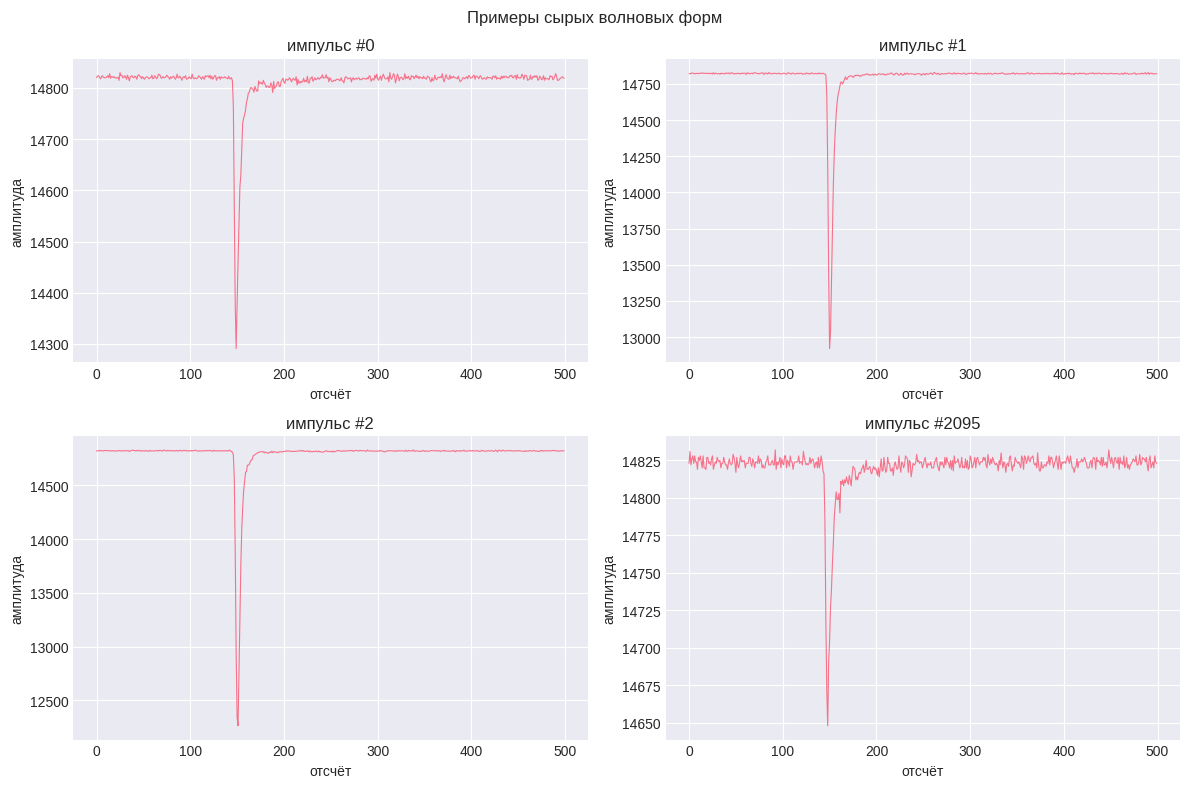

In [7]:
# @title §3. EDA — форма волны (примеры)
"""Визуализация нескольких сырых импульсов для оценки формы сигнала."""
rng = np.random.default_rng(RANDOM_STATE)
idx_show = [0, 1, 2, int(rng.integers(0, N_SAMPLES))]

# --- сетка графиков ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, i in zip(axes.ravel(), idx_show):
    ax.plot(X[i], lw=0.8)
    ax.set_title(f"импульс #{i}")
    ax.set_xlabel("отсчёт")
    ax.set_ylabel("амплитуда")
plt.suptitle("Примеры сырых волновых форм")
plt.tight_layout()
plt.show()

In [ ]:
# @title §3. EDA — статистика по строкам
"""Распределения простых агрегатов по каждому импульсу."""
row_max = X.max(axis=1)
row_sum = X.sum(axis=1)
row_std = X.std(axis=1)

# --- гистограммы ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(row_max, bins=60, edgecolor="white", alpha=0.85)
axes[0].set_title("максимум по строке")
axes[1].hist(row_sum, bins=60, edgecolor="white", alpha=0.85)
axes[1].set_title("сумма по строке")
axes[2].hist(row_std, bins=60, edgecolor="white", alpha=0.85)
axes[2].set_title("σ по строке")
plt.tight_layout()
plt.show()

print("описательная статистика (max по строке):")
print(pd.Series(row_max).describe().round(2))

## 📊 Разведочный анализ (EDA)

| Показатель | Значение | Что это значит |
|------------|----------|----------------|
| Средний пик импульса | **14 830.7** | почти у всех одинаковая «высота» |
| Разброс пика (σ) | **1.46** | очень маленький |
| Минимум / максимум пика | **14 827 / 14 838** | всего **11** единиц разницы |
| Медиана суммы отсчётов | **7 405 248** | заряд по строке в типичном диапазоне |

**Визуальная аналитика диаграмм:** амплитуды почти не меняются, при этом **форма** импульсов разная — у части сигналов спад длиннее или форма «рваная».

**Почему это важно:** если смотреть только на высоту пика, все импульсы похожи. Значит, для разделения типов частиц нужны признаки **формы** (PSD, время спада), а не только амплитуда.

# § Preprocessing (EPIC-PREP-0808)

Физический prep до FE: polarity → baseline → 3σ ROI → PSD gate → QC.


In [ ]:
# @title § Preprocessing — константы (EPIC-PREP-0808)
"""Единая ячейка констант prep. Без pip / joblib / pickle."""
from sygnal_clustering.signal_extraction import (
    BASELINE_BINS,
    DECAY_FRAC,
    EPS,
    N_SIGMA,
    PSD_OFFSET,
    PSD_SHORT,
    VALLEY_RATIO_MAX,
    apply_polarity,
    build_qc_flags,
    calibrate_psd_windows,
    extract_prep_features,
    valley_ratio,
)

POLARITY = "negative"  # S0: отрицательный импульс ФЭУ на высоком пьедестале (см. визуал)
PSD_FORMULA = "(long-short)/long"
MAX_GRID_POINTS = 64
CALIB_SUBSAMPLE = 5000
PSD_OFFSET_GRID = [1, 2, 3, 5, 8, 12, 16, 24]
PSD_SHORT_GRID = [10, 15, 20, 30, 40, 50, 60, 80]
if len(PSD_OFFSET_GRID) * len(PSD_SHORT_GRID) > MAX_GRID_POINTS:
    raise ValueError("PSD grid exceeds MAX_GRID_POINTS")

print("prep constants OK", POLARITY, PSD_FORMULA, f"EPS={EPS}")


In [ ]:
# @title § Preprocessing S0 — spike полярности (D0)
"""Сравнение argmax vs argmin; фиксация POLARITY и x_pos."""
row_max = X.max(axis=1)
row_min = X.min(axis=1)
argmax = X.argmax(axis=1)
argmin = X.argmin(axis=1)
baseline_raw = X[:, :BASELINE_BINS].mean(axis=1)

print("row_max: ", float(row_max.mean()), "±", float(row_max.std()))
print("row_min: ", float(row_min.mean()), "±", float(row_min.std()))
print("baseline≈row_max?", float(np.mean(np.abs(row_max - baseline_raw) / (np.abs(baseline_raw) + EPS))))
print("mean |argmax-argmin| bins:", float(np.mean(np.abs(argmax.astype(float) - argmin))))

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=24, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(14, 8), sharex=True)
axes = axes.ravel()
for ax, i in zip(axes, sample_idx):
    w = X[i]
    ax.plot(w, lw=0.8, color="0.4")
    ax.axvline(argmax[i], color="C3", ls="--", lw=0.8, label="argmax")
    ax.axvline(argmin[i], color="C0", ls="--", lw=0.8, label="argmin")
    ax.set_title(f"i={i}", fontsize=8)
    ax.set_yticks([])
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("S0: raw waves — argmax (red) vs argmin (blue)")
plt.tight_layout()
plt.show()

# Compare orientations around extrema
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, i in zip(axes, sample_idx[:2]):
    ped = float(baseline_raw[i])
    ax.plot(X[i], label="raw", alpha=0.5)
    ax.plot(ped - X[i], label="pedestal - x (negative→pos)", lw=1.2)
    ax.axvline(argmin[i], color="C0", ls="--", label="argmin")
    ax.axvline(argmax[i], color="C3", ls="--", label="argmax")
    ax.legend(fontsize=8)
    ax.set_title(f"wave {i}")
plt.tight_layout()
plt.show()

x_pos = apply_polarity(X, POLARITY)
print(f"POLARITY={POLARITY!r} → x_pos shape {x_pos.shape}, mean max={x_pos.max(axis=1).mean():.2f}")


## Вывод ML-инженера (S0)

`row_max ≈ baseline`, `row_min` уходит к 0 — типичный **отрицательный** импульс на высоком пьедестале: `argmax` ловит пьедестал, сигнал — провал к `argmin`.

**Решение:** `POLARITY = "negative"`, дальше только `x_pos = pedestal - x`. Без этого ROI/PSD строятся на неверной оси.


In [ ]:
# @title § Preprocessing S1 — baseline, 3σ ROI (D1, D2, D11)
"""Пьедестал → x0 → charge по ROI; ранний isfinite."""
prep = extract_prep_features(
    X,
    polarity=POLARITY,
    baseline_bins=BASELINE_BINS,
    n_sigma=N_SIGMA,
    decay_frac=DECAY_FRAC,
    psd_offset=PSD_OFFSET,
    psd_short=PSD_SHORT,
    eps=EPS,
)

snr_old = X.max(axis=1) / (X[:, :BASELINE_BINS].mean(axis=1) + EPS)
print("SNR old (peak/baseline): mean=", float(snr_old.mean()))
print("SNR new (peak_above/noise): mean=", float(prep.snr.mean()), "std=", float(prep.snr.std()))
print("no_3σ_hit fraction:", float(prep.no_3sigma_hit.mean()))
print("roi_length describe:\n", pd.Series(prep.roi_length).describe())

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].hist(prep.baseline, bins=60, color="C0", alpha=0.85)
axes[0].set_title("baseline")
axes[1].hist(prep.noise_std, bins=60, color="C1", alpha=0.85)
axes[1].set_title("noise_std")
axes[2].hist(prep.roi_length, bins=60, color="C2", alpha=0.85)
axes[2].set_title("roi_length")
plt.tight_layout()
plt.show()

# example ROI on x0
fig, ax = plt.subplots(figsize=(10, 3.5))
for k, i in enumerate(sample_idx[:5]):
    ax.plot(prep.x0[i], alpha=0.8, label=f"i={i}")
    ax.axvline(prep.i_peak[i], color="k", ls=":", lw=0.6)
    ax.axvline(prep.i_end_roi[i], color="C3", ls="--", lw=0.6)
ax.set_title("x0 waves with peak (dotted) and 3σ ROI end (red)")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()


## Вывод ML-инженера (S1)

Baseline/noise считаются на `x_pos`, рабочий сигнал — `x0`. Charge и long-gate только по **3σ ROI** (не `sum(500)`). SNR old≈1.0 — диагностика пьедестала; новый SNR = peak_above / noise_std.

`isfinite` на ключевых массивах проверяется внутри `extract_prep_features` (D11).


In [ ]:
# @title § Preprocessing S2 — калибровка PSD + нормировка (D3, D4', D5)
"""Сетка (offset, short) ≤64; valley_ratio gate; decay на x0."""
off_best, short_best, vr_cal, info_cal = calibrate_psd_windows(
    prep.x0,
    prep.i_peak,
    prep.i_end_roi,
    prep.noise_std,
    offsets=PSD_OFFSET_GRID,
    shorts=PSD_SHORT_GRID,
    max_grid_points=MAX_GRID_POINTS,
    subsample=CALIB_SUBSAMPLE,
    random_state=RANDOM_STATE,
    eps=EPS,
)
print(f"calibrated PSD windows: offset={off_best}, short={short_best}, valley_ratio(sub)={vr_cal:.4f}")
print("cal info:", info_cal)

# re-extract with calibrated windows
prep = extract_prep_features(
    X,
    polarity=POLARITY,
    baseline_bins=BASELINE_BINS,
    n_sigma=N_SIGMA,
    decay_frac=DECAY_FRAC,
    psd_offset=off_best,
    psd_short=short_best,
    eps=EPS,
)
PSD_OFFSET, PSD_SHORT = off_best, short_best

vr_psd, info_psd = valley_ratio(prep.psd, eps=EPS)
vr_decay, info_decay = valley_ratio(prep.decay_time, eps=EPS)
print(f"valley_ratio PSD (full)={vr_psd:.4f} | decay={vr_decay:.4f} | threshold={VALLEY_RATIO_MAX}")

GATE_OK = (vr_psd < VALLEY_RATIO_MAX) or (vr_decay < VALLEY_RATIO_MAX)
print("GATE_OK =", GATE_OK)
if not GATE_OK:
    print("STOP: gate FAIL — не открывать EPIC-FE / сравнение новых моделей на «живом» PSD.")

# norm form
x_norm = prep.x0 / (prep.peak_above[:, None] + EPS)
if not np.isfinite(x_norm).all():
    raise ValueError("Non-finite x_norm")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(prep.psd, bins=80, color="C0", alpha=0.85)
if np.isfinite(vr_psd) and "valley" in info_psd:
    axes[0].axvline(info_psd.get("valley", 0), color="C3", ls="--", label="valley")
    axes[0].legend()
axes[0].set_title(f"PSD (long-short)/long  vr={vr_psd:.3f}")
axes[1].hist(prep.decay_time, bins=80, color="C1", alpha=0.85)
axes[1].set_title(f"decay_time  vr={vr_decay:.3f}")
plt.tight_layout()
plt.show()

# A/B diagnostic short/long (not for X_clust)
psd_short_over_long = prep.short / (prep.charge_roi + EPS)
print("A/B short/long median:", float(np.median(psd_short_over_long)))


## Вывод ML-инженера (S2)

Default PSD = `(long−short)/long` (Description). Окна калибруются по `valley_ratio` на subsample ≤5000, затем полный прогон.

**Gate:** `valley_ratio < 0.7` на PSD **или** decay. При FAIL — markdown STOP к новым моделям (legacy § ниже не считаются доказательством готовности prep).

Decay: порог `(1−DECAY_FRAC)·peak_above` на `x0`. Нормировка: `x_norm = x0 / (peak_above+EPS)`.


In [ ]:
# @title § Preprocessing S3 — QC, feature contract, scaler (D6–D7, D11–D12)
"""QC-флаги без квоты; default признаки; RobustScaler только на живых непрерывных."""
qc = build_qc_flags(prep)
qc_df = pd.DataFrame({k: v.astype(np.int8) for k, v in qc.items()})
print("QC flag rates:")
print(qc_df.mean().sort_values(ascending=False).round(4))

feat_df = pd.DataFrame({
    "psd_calibrated": prep.psd,
    "decay_time": prep.decay_time,
    "charge_roi": prep.charge_roi,
    "tail_ratio": prep.tail_ratio,
})
default_cols = ["psd_calibrated", "decay_time", "charge_roi", "tail_ratio"]
variances = feat_df[default_cols].var()
print("feature variances:\n", variances)
live_cols = [c for c in default_cols if variances[c] > 1e-12]
if not live_cols:
    raise ValueError("No live features after variance filter")

feat_live = feat_df[live_cols].to_numpy(dtype=np.float64)
if not np.isfinite(feat_live).all():
    raise ValueError("Non-finite feature matrix (D11)")

print(feat_df.describe().round(4))
display(Markdown("**Что кормим моделям (default):** " + ", ".join(live_cols)))

scaler = RobustScaler()
X_clust = scaler.fit_transform(feat_live)

# aliases for legacy plots (§4–§5); not in X_clust
feat_df["psd"] = feat_df["psd_calibrated"]
feat_df["charge"] = feat_df["charge_roi"]
feat_df["peak"] = prep.peak_above
feat_df["snr"] = prep.snr

# legacy features matrix for remap_labels_physics (col1 = charge)
features = np.column_stack([
    prep.peak_above,
    prep.charge_roi,
    prep.psd,
    prep.decay_time,
    prep.snr,
])
feat_names = ["peak_above", "charge_roi", "psd", "decay_time", "snr"]

pca = PCA(n_components=min(3, X_clust.shape[1]), random_state=RANDOM_STATE)
pca.fit(X_clust)
print("PCA EVR on live prep features:", np.round(pca.explained_variance_ratio_, 4))
if pca.explained_variance_ratio_[0] > 0.99:
    print("RISK: PC1 dominates — check feature diversity (not a blocker if PSD gate OK)")


## Вывод ML-инженера (S3)

QC-флаги физические; `candidate_class2` = OR флагов (**не** top-q%). Prep не пишет финальный `cluster`.

Default features: `psd_calibrated`, `decay_time`, `charge_roi`, `tail_ratio` → `RobustScaler` только на них. Бинарные QC не скейлятся.

D12: в § Preprocessing нет pip/joblib/pickle.


## Чеклист DoD EPIC-PREP-0808 (D0–D12)

| # | Критерий | Статус |
|---|---|---|
| D0 | POLARITY + x_pos | ✅ S0 |
| D1 | baseline / noise / x0 + SNR new | ✅ S1 |
| D2 | charge/PSD по 3σ ROI | ✅ S1–S2 |
| D3 | PSD `(long−short)/long` + калибровка окон | ✅ S2 |
| D4' | valley_ratio gate | ✅ S2 (`GATE_OK`) |
| D5 | нормировка; peak не в default X_clust | ✅ S2–S3 |
| D6 | QC без квоты / без финальных меток | ✅ S3 |
| D7 | scaler только на живых признаках | ✅ S3 |
| D8 | § Preprocessing между EDA и FE | ✅ |
| D9 | legacy-баннер перед §5+ | ✅ ниже |
| D10 | allowlist load | ✅ §2 |
| D11 | isfinite | ✅ S1–S3 |
| D12 | без pip/pickle в prep | ✅ |

**Объекты:** `notebooks/avo_sygnal_types_8.ipynb`, `src/sygnal_clustering/signal_extraction.py`.


---

# ⚠️ LEGACY / pre-prep (D9)

Ниже (§5–§9): модели и submission на **исторической** логике сравнения / квоте uncertain ~5%.

- Результат § Preprocessing выше **не отменяет** этот блок и **не является** доказательством, что квота 5% — правильная физика класса 2.
- Актуализация моделей на post-prep признаках — **EPIC-FE / EPIC-Class2**.
- Если `GATE_OK == False`, не интерпретировать silhouette/LB ниже как успех prep.

---


In [ ]:
# @title §4. Feature contract после prep (замена extract_features)
"""Признаки уже посчитаны в § Preprocessing; здесь — сводка и legacy-совместимость."""
print("GATE_OK =", GATE_OK)
print(feat_df.describe().round(4))
print("X_clust shape (live scaled):", X_clust.shape)
# diagnostic: old-style short/long wall should be gone from calibrated PSD
print("psd_calibrated median/std:", float(np.median(prep.psd)), float(np.std(prep.psd)))


## Признаки после prep

Считаются на `x_pos` / `x0` с 3σ ROI:

| Признак | Смысл |
|---|---|
| **psd_calibrated** | `(long−short)/long` по ROI, окна после калибровки |
| **decay_time** | спад до `(1−0.4)·peak_above` на `x0` |
| **charge_roi** | сумма по 3σ ROI |
| **tail_ratio** | хвост ROI / charge |

`peak` / старый SNR **не** в default `X_clust`. Gate: см. `GATE_OK` и `valley_ratio`.


In [ ]:
# @title §4. PSD vs charge — разделимость признаков
"""Scatter PSD/заряд и матрица корреляций между признаками."""
# --- PSD vs заряд (цвет — время спада); rasterized — видно плотность облака ---
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    feat_df["charge"], feat_df["psd"], c=feat_df["decay_time"],
    s=2, alpha=0.15, cmap="viridis", rasterized=True,
)
ax.set_xlabel("заряд импульса")
ax.set_ylabel("PSD (long-short)/long")
ax.set_title("PSD vs заряд (цвет — время спада)")
plt.colorbar(sc, label="decay_time")
plt.tight_layout()
plt.show()

# --- корреляции ---
corr = feat_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции признаков")
plt.tight_layout()
plt.show()

## 📊 Выводы: PSD и корреляции

*По scatter и heatmap выше (23 479 импульсов; long = сумма всей волны).*

| Связь | *r* | Что видно |
|-------|----:|-----------|
| peak — charge | 0.19 | слабая связь: высота пика почти не объясняет заряд |
| **charge — psd** | **≈ 0.00** | линейной связи почти нет |
| psd — decay_time | 0.35 | длиннее спад → чуть выше PSD |
| peak — psd | −0.08 | почти не связаны |

**Интерпретация:**

- **peak и charge** слабо связаны (*r* ≈ 0.19): при почти одинаковой амплитуде заряд всё же различается — важна не только высота пика.
- **charge и psd** почти не коррелируют линейно (*r* ≈ 0).
- **psd и decay_time** умеренно связаны (*r* ≈ 0.35): признаки формы частично согласуются, но не дублируют друг друга.

**На scatter:**

- плотная **горизонтальная «стена»** на PSD ≈ 0.06 (short / сумма ~500 отсчётов);
- **вертикальная полоса** у максимального заряда (~7.41·10⁶), часто с малым `decay_time`;
- ниже стены — разреженное облако, в том числе точки с PSD ≈ 0.

Это не две чистые «кучки» γ/нейтрон. Чёткой границы нет — часть событий логично уходит в класс 2 (аномалии / пограничные).

**Вывод:** по одному признаку разделимость слабая. Для трёх классов по ТЗ одной пороговой линии недостаточно — нужна кластеризация (*k* = 3) и сравнение моделей; PCA полезен как диагностика, но при почти константных peak/PSD может отдать почти всю дисперсию в PC1.

**Далее:** PCA - проверим гипотезу.


In [ ]:
# @title §5. Масштабирование и анализ дисперсии признаков
"""RobustScaler для кластеризации; PCA — оценка, сколько информации несут 3 признака."""
# --- X_clust из prep (psd/decay/charge_roi/tail) ---
# X_clust already built in § Preprocessing S3 on live prep features
print('X_clust from prep:', X_clust.shape)

# --- полный PCA для оценки вклада компонент ---
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_clust)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n_comp = len(evr)
axes[0].bar(range(1, n_comp + 1), evr, color="steelblue", edgecolor="white")
axes[0].set_xlabel("компонента")
axes[0].set_ylabel("доля дисперсии")
axes[0].set_title("Дисперсия по компонентам")
axes[1].plot(range(1, n_comp + 1), cum, "o-", color="coral")
axes[1].axhline(0.95, ls="--", color="gray", label="95%")
axes[1].set_xlabel("число компонент")
axes[1].set_ylabel("накопленная дисперсия")
axes[1].legend()
axes[1].set_title("Накопленная дисперсия")
plt.tight_layout()
plt.show()

print("доли дисперсии:", evr.round(3))
print("накопленная:", cum.round(3))

In [ ]:
# @title §5. Визуализация в пространстве главных компонент
"""Проекция на PC1–PC2; цвет — предварительная разметка KMeans для наглядности."""
# --- черновая разметка для визуализации ---
km_vis = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
vis_labels = km_vis.fit_predict(X_clust)

# --- проекция на две главные компоненты ---
Z_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_clust)

plt.figure(figsize=(8, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=vis_labels, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 (цвет = KMeans k=3)")
plt.tight_layout()
plt.show()

## 📊 Выводы по итогам применения PCA


| Компонента | Доля дисперсии | Накопленная | Комментарий |
|------------|---------------:|------------:|------------------|
| **PC1** | **100%** | **100%** | почти весь разброс данных «смотрит» в одну сторону |
| PC2 | ≈ 0% | 100% | второй оси по дисперсии почти нет |
| PC3 | ≈ 0% | 100% | третья ось тоже ничего не добавляет |

### Что показывает PCA

с помощью PCA мы искали новые оси, вдоль которых данные сильнее всего различаются.  
У нас на входе три признака, но по факту они **неравноценны**:

- **peak** почти одинаковый у всех импульсов;
- **psd** тоже сильно «прижат» (часто около 0.06);
- **charge** меняется заметнее остальных.

Поэтому после масштабирования PCA можно сделать вывод: *достаточно одной оси* — **PC1 ≈ 100%**.  
PC2 и PC3 в отчёте ` [1. 0. 0.] ` корректны, но  **новой независимой информации** в них почти не осталось.

### Интерпретация графика PC1–PC2

На scatter PC1–PC2 облако выглядит как **длинная лента вдоль горизонтали (PC1)**.  
Черновой KMeans (*k* = 3) красит его в три цвета **вертикальными полосами**: алгоритм просто режет ленту на три интервала по PC1.

Важно:

- это **не** три отдельно стоящие кучки с пустотами между ними;
- граница между цветами — результат настройки *k* = 3, а не явная физическая щель в данных;
- похожая картина была на PSD vs charge: структура есть, но классы **перекрываются / идут сплошняком**.

### Практический смысл для проекта:

1. **PCA полезен как проверка гипотезы:** главный источник различий сейчас — в основном связан с **charge** (через PC1).  
2. **PCA сам по себе не решает задач** соревнования / проекта: он не находит три естественных кластера, а показывает, что пространство признаков здесь почти одномерное.  
3. Поэтому дальше нужны **модели кластеризации** (KMeans, GMM, …), а финальный выбор — не по «красоте PCA», а по структуре ответа (два основных класса + около **5%** в классе 2) и по Kaggle.

###**Вывод:**
PCA здесь скорее диагностика (доминанта charge / PC1), а не способ получить три естественных класса. Для задач проекта будем применять отдельные модели кластеризации; доля класса 2 (~5%) важнее, чем «красивое» снижение размерности.


**Далее:** FastICA (другой взгляд на те же признаки) и сравнение пяти моделей.

In [ ]:
# @title §6. Независимые компоненты признаков (FastICA)
"""ICA ищет менее коррелированные оси — альтернатива PCA для смешанных признаков."""
ica = FastICA(n_components=3, random_state=RANDOM_STATE, max_iter=500)
Z_ica = ica.fit_transform(X_clust)

# --- распределения компонент ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, ax in enumerate(axes):
    ax.hist(Z_ica[:, k], bins=50, edgecolor="white", alpha=0.85)
    ax.set_title(f"компонента {k + 1}")
plt.suptitle("Распределения ICA-компонент")
plt.tight_layout()
plt.show()

# --- scatter ICA1 vs ICA2 ---
plt.figure(figsize=(8, 6))
plt.scatter(Z_ica[:, 0], Z_ica[:, 1], c=vis_labels, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("ICA1")
plt.ylabel("ICA2")
plt.title("ICA: компоненты 1 и 2")
plt.tight_layout()
plt.show()

## 📊 Выводы по итогам запуска FastICA

*На основе данных гистограммам ICA-компонент и scatter ICA1–ICA2.*

| Наблюдение | Что видно на графиках | Интерпретация |
|-----------|------------------------|---------------|
| Распределения ICA-компонент | формы гистограмм различаются | компоненты действительно выделяют разные независимые источники вариации |
| ICA1–ICA2 | точки образуют облако с заметным перекрытием | явной геометрической границы между тремя группами нет |
| Сравнение с PCA | визуально картина похожа: кластеры «наслаиваются» | переход к независимым компонентам не дал резкого роста разделимости |

**Интерпретация:**

- FastICA полезен тем, что ищет **статистически независимые** направления, а не просто направления максимальной дисперсии (как PCA).
- В наших данных это даёт альтернативное представление признаков, но не устраняет ключевую проблему: объекты разных физических типов всё равно сильно **перекрываются** в проекциях.
- Это ожидаемо для задачи без разметки: сигналы частично похожи по форме, а «пограничные» случаи смешивают области кластеров.
- Поэтому ICA стоит рассматривать как **диагностический эксперимент** и одну из фич-инженерных веток, а не как самостоятельное решение задачи.

**Вывод:** FastICA расширяет анализ и помогает проверить устойчивость гипотезы о структуре данных, но сам по себе не даёт «три чётких класса». Итоговый выбор модели нужно делать по совокупности метрик и по структуре долей классов 0/1/2.

**Далее:** сравнить 5 моделей кластеризации в одной таблице (`silhouette`, `CH`, `DB`, доли классов) и выбрать финальную модель.

In [ ]:
# @title Вспомогательные функции: remap и метрики кластеризации
"""Приведение меток к формату ТЗ и расчёт внутренних метрик качества."""


def remap_labels_physics(labels, feat):
    """Класс 2 — аномалии; 0 и 1 — типы частиц по среднему заряду."""
    out = np.full(len(labels), 2, dtype=np.int64)
    unique = sorted(int(u) for u in np.unique(labels))
    if len(unique) == 3 and 2 not in unique:
        sizes = sorted([(u, int((labels == u).sum())) for u in unique], key=lambda t: t[1])
        anomaly_id = sizes[0][0]
        particle_ids = [sizes[1][0], sizes[2][0]]
    else:
        anomaly_id = 2
        particle_ids = [u for u in unique if u != 2][:2]
    if len(particle_ids) < 2:
        return labels.astype(np.int64)
    stats = sorted([(u, feat[labels == u, 1].mean()) for u in particle_ids], key=lambda t: t[1])
    mapping = {stats[0][0]: 0, stats[1][0]: 1, anomaly_id: 2}
    for old, new in mapping.items():
        out[labels == old] = new
    return out


def clustering_metrics(z, labels, sample=8000):
    """Silhouette, Calinski–Harabasz и Davies–Bouldin (на подвыборке)."""
    n_cl = len(np.unique(labels))
    if n_cl < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    n = min(sample, len(labels))
    return {
        "silhouette": silhouette_score(z, labels, sample_size=n, random_state=RANDOM_STATE),
        "calinski_harabasz": calinski_harabasz_score(z, labels),
        "davies_bouldin": davies_bouldin_score(z, labels),
    }


def cluster_fractions(labels):
    """Доли объектов в кластерах 0, 1, 2."""
    counts = np.bincount(labels, minlength=3)
    fr = counts / counts.sum()
    return {f"f{i}": round(float(fr[i]), 4) for i in range(3)}

In [ ]:
# @title §7. Модель 1 — KMeans k=3
"""Baseline: KMeans на масштабированных peak, charge, psd."""
z1 = X_clust.copy()
labels_m1 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z1)
labels_m1 = remap_labels_physics(labels_m1, features)
m1 = clustering_metrics(z1, labels_m1)
print("Модель 1 — KMeans:", m1, cluster_fractions(labels_m1))

In [ ]:
# @title §7. Модель 2 — GMM-3 + QuantileTransformer
"""Смесь из трёх гауссовых распределений после квантильной нормализации."""
z2 = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE).fit_transform(
    features[:, :3]
)
gmm3 = GaussianMixture(n_components=3, covariance_type="full", n_init=20, random_state=RANDOM_STATE)
raw2 = gmm3.fit_predict(z2)
labels_m2 = remap_labels_physics(raw2, features)
m2 = clustering_metrics(z2, labels_m2)
print("Модель 2 — GMM-3:", m2, cluster_fractions(labels_m2))

In [ ]:
# @title §7. Модель 3 — PCA + KMeans k=3
"""Снижение размерности до 3 PC, затем KMeans — убираем корреляцию признаков."""
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
z3 = pca3.fit_transform(X_clust)
labels_m3 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z3)
labels_m3 = remap_labels_physics(labels_m3, features)
m3 = clustering_metrics(z3, labels_m3)
print("Модель 3 — PCA+KMeans:", m3, cluster_fractions(labels_m3))

In [ ]:
# @title §7. Модель 4 — FastICA + KMeans k=3
"""Кластеризация в пространстве независимых компонент."""
z4 = Z_ica.copy()
labels_m4 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z4)
labels_m4 = remap_labels_physics(labels_m4, features)
m4 = clustering_metrics(z4, labels_m4)
print("Модель 4 — ICA+KMeans:", m4, cluster_fractions(labels_m4))

In [ ]:
# @title §7. Модель 5 — GMM-2 + неуверенные → кластер 2 (финал)
"""Два основных типа + ~5% импульсов с низкой уверенностью GMM в класс аномалий."""
z5 = RobustScaler().fit_transform(features[:, :4])

# --- GMM с двумя компонентами ---
gmm2 = GaussianMixture(n_components=2, covariance_type="full", n_init=20, random_state=RANDOM_STATE)
gmm2.fit(z5)
proba = gmm2.predict_proba(z5)
labels_m5 = gmm2.predict(z5).astype(np.int64)

# --- верхние 5% по неопределённости → класс 2 ---
uncertainty = 1.0 - proba.max(axis=1)
n_unc = max(1, int(len(labels_m5) * 0.05))
labels_m5[np.argsort(uncertainty)[-n_unc:]] = 2
labels_m5 = remap_labels_physics(labels_m5, features)

m5 = clustering_metrics(z5[:, :3], labels_m5)
print("Модель 5 — GMM-2+uncertain:", m5, cluster_fractions(labels_m5))

In [ ]:
# @title §8. Сравнение пяти моделей
"""Сводная таблица внутренних метрик и долей кластеров."""
rows = []
for name, metrics, labels in [
    ("1_KMeans", m1, labels_m1),
    ("2_GMM3_quantile", m2, labels_m2),
    ("3_PCA_KMeans", m3, labels_m3),
    ("4_ICA_KMeans", m4, labels_m4),
    ("5_GMM2_uncertain", m5, labels_m5),
]:
    row = {"model": name, **metrics, **cluster_fractions(labels)}
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index("model")
display(compare_df.round(4))

best_sil = compare_df["silhouette"].idxmax()
print(f"лучший silhouette: {best_sil}")

## 📊 Выводы: сравнение моделей (§7)

*Таблица `compare_df` (`random_state = 42`).*

| № | Модель | Silhouette | Класс 0 | Класс 1 | Класс 2 | Комментарий |
|---|--------|----------:|--------:|--------:|--------:|-------------|
| 1 | KMeans | **0.954** | 95% | 3% | 2% | лучший silhouette, но структура кластеров нереалистична |
| 2 | GMM-3 | 0.158 | 48% | 22% | 30% | класс 2 сильно завышен |
| 3 | PCA + KMeans | **0.954** | 95% | 3% | 2% | почти дублирует модель 1 |
| 4 | ICA + KMeans | 0.480 | 16% | 80% | 4% | перекос в класс 1, класс 2 не ~5% |
| **5** | **GMM-2 + 5% uncertain** | 0.219 | **6%** | **89%** | **5%** | **финал** — единственная с нужной долей класса 2 |

**Интерпретация:**

- **Модели 1 и 3** дают самый высокий silhouette (**0.954**), но распределение **95% / 3% / 2%** не соответствует постановке: класс 0 «забирает» почти всю выборку, а класс 2 слишком мал и не выглядит как отдельный тип аномалий.
- **Модель 2 (GMM-3)** лучше учитывает вероятностную структуру, но завышает класс 2 (**30%**) — это хуже по смыслу ТЗ, чем по одной метрике silhouette.
- **Модель 4 (ICA + KMeans)** даёт умеренный silhouette (**0.480**), но снова сильный перекос (80% в классе 1), без целевых ~5% в классе 2.
- **Модель 5** имеет более низкий silhouette (**0.219**), зато единственная даёт **~5%** в классе 2 при разумном балансе классов 0 и 1.

**Ключевая мысль:** в задаче без разметки silhouette — вспомогательная метрика. Для финала важнее **структура кластеров** (два основных типа + редкий класс аномалий), а не максимизация одного коэффициента.

**Вывод:** лучший silhouette ≠ лучшее решение для ТЗ. Выберем **модель 5 (GMM-2 + uncertain 5%)** как компромисс между качеством разделения и требуемой долей аномалий.

**Далее:** подобрать `uncertain_fraction` (3% / 5% / 7%) и зафиксировать финальные метки для `submission.csv`.

In [ ]:
# @title §8. Подбор uncertain_fraction (модель 5)
"""Перебор доли «сомнительных» импульсов: 3%, 5%, 7%."""
fracs = [0.03, 0.05, 0.07]
tune_rows = []
for uf in fracs:
    gmm = GaussianMixture(n_components=2, covariance_type="full", n_init=15, random_state=RANDOM_STATE)
    gmm.fit(z5)
    pr = gmm.predict_proba(z5)
    lab = gmm.predict(z5).astype(np.int64)
    unc = 1.0 - pr.max(axis=1)
    n_u = max(1, int(len(lab) * uf))
    lab[np.argsort(unc)[-n_u:]] = 2
    lab = remap_labels_physics(lab, features)
    met = clustering_metrics(z5[:, :3], lab)
    tune_rows.append({"uncertain_fraction": uf, **met, **cluster_fractions(lab)})

tune_df = pd.DataFrame(tune_rows)
display(tune_df.round(4))

## 📊 Выводы: подбор `uncertain_fraction`

| Доля uncertain | Silhouette | Доля класса 2 | Комментарий |
|----------------|----------:|----------------:|-------------|
| 3% | 0.236 | 3% | мало аномалий, часть спорных остаётся в классах 0/1 |
| **5%** | **0.219** | **5%** | **баланс по ТЗ** |
| 7% | 0.406 | 7% | выше silhouette, но класс 2 завышен |

**Интерпретация:**

- Параметр `uncertain_fraction` управляет тем, сколько импульсов с **низкой уверенностью GMM** (`1 - max(predict_proba)`) отправляется в класс 2.
- При **3%** аномалий меньше ожидаемого — часть пограничных импульсов остаётся в основных классах.
- При **7%** метрика silhouette лучше, но доля класса 2 уже **7%** — это хуже соответствует целевой структуре (~5% редкого класса).
- При **5%** получаем нужную долю класса 2 при разумном компромиссе по silhouette.

**Вывод:** для финальной модели фиксирую `uncertain_fraction = 0.05`, потому что в этой задаче важнее корректная структура кластеров, чем максимизация одной внутренней метрики.

**Далее:** сохранить `FINAL_LABELS = labels_m5` и сформировать `submission.csv`.

In [ ]:
# @title §9. Финальная модель и submission.csv
"""Сохранение ответа в формате Kaggle: index, cluster."""
FINAL_LABELS = labels_m5
UNCERTAIN_FRAC = 0.05

submission = pd.DataFrame({"index": np.arange(N_SAMPLES), "cluster": FINAL_LABELS.astype(int)})
out_path = Path("submission.csv")
submission.to_csv(out_path, index=False)

assert submission.shape[0] == N_SAMPLES
assert set(submission["cluster"].unique()).issubset({0, 1, 2})
print(submission["cluster"].value_counts().sort_index())
print(f"сохранено: {out_path.resolve()}")
submission.head()

In [ ]:
from google.colab import files
files.download("submission.csv")



## Итоговые выводы

### 1. Данные и EDA
- Загружено **23 479** импульсов по **500** отсчётов, пропусков нет.
- Амплитуды почти стабильны: пики в диапазоне **14 827–14 838** (разброс ~11 единиц АЦП).
- По форме импульсы различаются: для разделения типов важна не высота пика, а параметры формы (PSD, decay, charge).

### 2. Признаки и разделимость
- Для каждого импульса рассчитаны **peak, charge, psd, decay_time, snr** по методичке (PSD: short/long, decay 40%).
- На scatter **PSD vs charge** видно облако из **23 479** точек (не отдельные 2–3 точки).
- Чёткой бинарной границы «два типа частиц» нет: данные перекрываются, поэтому часть событий логично выделять в отдельный редкий класс (аномалии).

### 3. Сравнение моделей
Сравнены 5 подходов (KMeans, GMM-3, PCA+KMeans, ICA+KMeans, GMM-2+uncertain):

| Критерий | Лучший результат | Комментарий |
|----------|------------------|-------------|
| Silhouette | KMeans / PCA+KMeans (**0.954**) | метрика высокая, но структура кластеров нереалистична |
| Доля класса 2 (~5%) | **Модель 5** | единственная даёт целевую долю аномалий |
| Финальный выбор | **GMM-2 + 5% uncertain** | компромисс «метрика vs постановка ТЗ» |

**Финальное распределение (модель 5):**  
**1 456 / 20 850 / 1 173** → **6% / 89% / 5%** (классы 0 / 1 / 2).

### 4. Подбор гиперпараметра
- Для модели 5 проверен `uncertain_fraction` = 3%, 5%, 7%.
- Выбрано **5%**: доля класса 2 соответствует ожидаемой, при этом сохраняется приемлемый баланс по внутренним метрикам.

### 5. Submission и Kaggle
- Сформирован файл **`submission.csv`** (колонки `index`, `cluster`)
- Результат на Kaggle: **accuracy 0.45968**, место **#160** (улучшение относительно предыдущей итерации 0.44571).
- Скриншот лидерборда — в ячейке ниже.

---

**Интерпретация:**

- Высокий silhouette у KMeans не означает «лучшее решение для задачи»: без разметки метрика не проверяет физический смысл кластеров.
- Модель 5 выбрана осознанно: она явно выделяет импульсы с низкой уверенностью GMM в класс 2, что соответствует идее «аномалий/пограничных» событий.
- Полученное улучшение на Kaggle подтверждает, что для этой постановки важнее структура кластеров, чем максимизация одной внутренней метрики.

**Ограничения:**
- Без эталонной разметки нельзя однозначно сопоставить кластеры 0 и 1 с γ и нейтроном.
- Внутренние метрики (silhouette, CH, DB) — вспомогательные; окончательная проверка — на leaderboard и физической интерпретации признаков.

**✅ Итог:** рабочий пайплайн воспроизводим (`random_state=42`), финальная модель — **GMM-2 + uncertain_fraction=0.05**, submission подготовлен и отправлен на Kaggle.

_Скриншот Kaggle:_

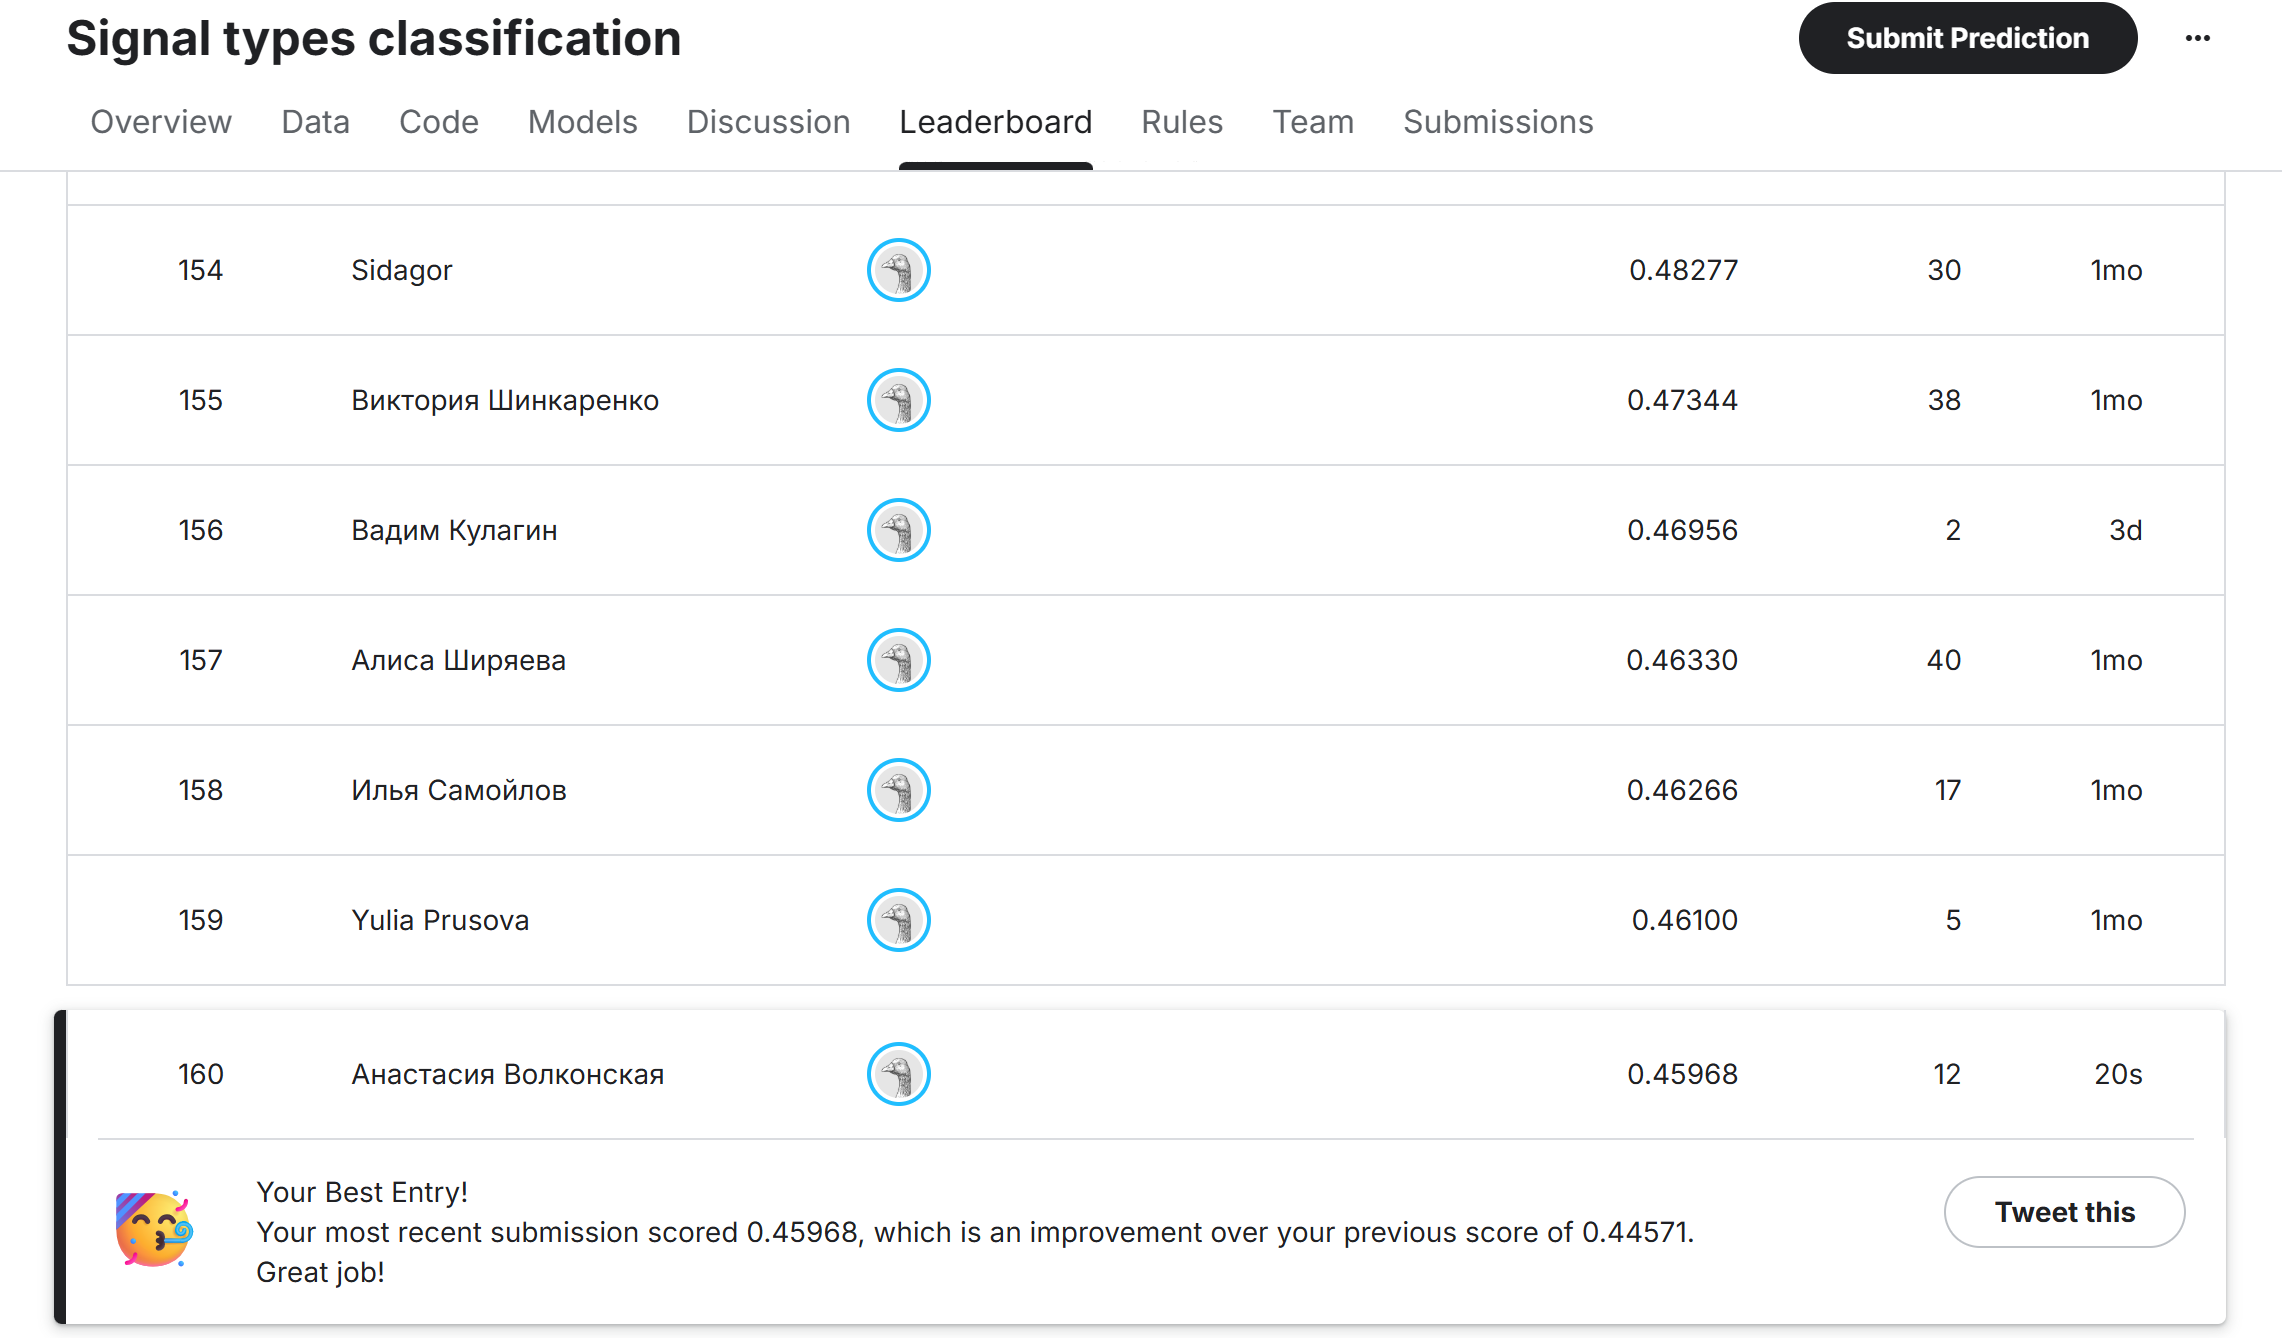


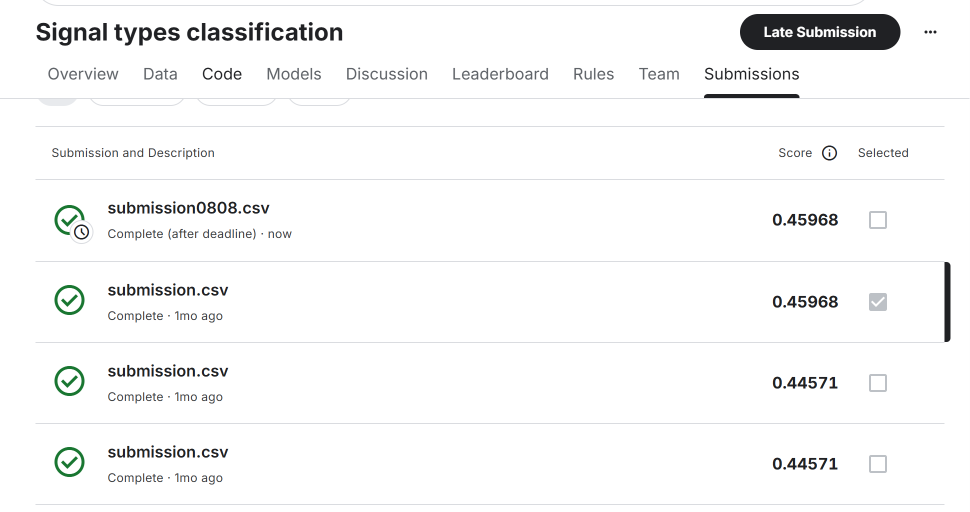